# ML & Sensing Final Project: Breathing Pattern Detection

**Authors**: Maanvi Sarwadi, Alina Zacaria

In [1]:
# Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import glob


from google.colab import drive
from scipy.fft import fft, fftfreq
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [9]:
try:
    drive.mount('/content/drive', force_remount=True)
    print("Drive mounted.")
except:
    print("Error mounting Drive, try running this cell again.")

Mounted at /content/drive
Drive mounted.


In [3]:
# Load dataset
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("arashnic/lung-dataset")

# print("Path to dataset files:", path)

In [10]:
def extract_audio_features(file_path):
    audio, sr = librosa.load(file_path, sr=22050)

    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
    zero_crossing_rate = librosa.feature.zero_crossing_rate(audio)

    features = np.hstack([
        np.mean(mfccs, axis=1),
        np.mean(spectral_centroid),
        np.mean(zero_crossing_rate)
    ])

    return features

In [13]:
# Column names for PhyPhox accelerometer CSV
# Adjust if your app exports different column names
DATA_ROOT   = "/content/drive/MyDrive/MLaS-final-ds"
ACCEL_COLS = {
    'time': 'time (s)',
    'x':    'Linear Acceleration x (m/s^2)',
    'y':    'Linear Acceleration y (m/s^2)',
    'z':    'Linear Acceleration z (m/s^2)',
}

PASSIVE_AUDIO_DIR = os.path.join(DATA_ROOT, "passive_audio")
ACTIVE_AUDIO_DIR = os.path.join(DATA_ROOT, "active_audio")
PASSIVE_ACCEL_DIR = os.path.join(DATA_ROOT, "passive_accelerator")

LABELS = {'normal': 0, 'irregular': 1}
CLASS_NAMES = ['Normal', 'Irregular']

        # root folder (see directory structure above)
AUDIO_SR    = 22050                                          # audio sample rate (Hz)
N_MFCC      = 13                                             # number of MFCC coefficients
ACCEL_SR    = 100                                            # accelerometer sample rate (Hz); PhyPhox default
BREATH_LOW  = 0.1                                            # breathing band lower bound (Hz) — ~6 breaths/min
BREATH_HIGH = 0.5                                            # breathing band upper bound (Hz) — ~30 breaths/min

# Matching feature names (used for importance plots later)
AUDIO_FEATURE_NAMES = (
    [f'mfcc_{i}_mean' for i in range(N_MFCC)] +
    [f'mfcc_{i}_std'  for i in range(N_MFCC)] +
    ['centroid_mean', 'centroid_std',
     'zcr_mean',      'zcr_std',
     'rms_mean',      'rms_std',
     'rolloff_mean',  'rolloff_std']
)

print(f"Audio feature vector length: {len(AUDIO_FEATURE_NAMES)}")


Audio feature vector length: 34


In [14]:
def load_passive_accel_files(accel_root):
    csv_files = []
    for folder in sorted(os.listdir(accel_root)):
        folder_path = os.path.join(accel_root, folder)
        if os.path.isdir(folder_path):
            csv_path = os.path.join(folder_path, "Accelerometer.csv")
            if os.path.exists(csv_path):
                csv_files.append(csv_path)
    return csv_files


def extract_accel_features(file_path, accel_sr=ACCEL_SR,
                           breath_low=BREATH_LOW, breath_high=BREATH_HIGH):
    """
    Returns a 1D feature vector from an accelerometer CSV.
    Total features: 15
    """
    df = load_passive_accel_files(file_path)

    # ── Time-domain features ─────────────────────────────────────────────────
    magnitude = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2).values

    time_features = np.array([
        np.mean(magnitude),
        np.std(magnitude),
        np.max(magnitude),
        np.min(magnitude),
        np.max(magnitude) - np.min(magnitude),  # range
        np.var(magnitude),
        np.mean(df['x'].values), np.std(df['x'].values),
        np.mean(df['y'].values), np.std(df['y'].values),
        np.mean(df['z'].values), np.std(df['z'].values),
    ])

    # ── Frequency-domain features (FFT) ──────────────────────────────────────
    n       = len(magnitude)
    freqs   = fftfreq(n, d=1.0 / accel_sr)
    fft_mag = np.abs(fft(magnitude))

    # Keep only positive frequencies
    pos_mask   = freqs > 0
    freqs_pos  = freqs[pos_mask]
    fft_pos    = fft_mag[pos_mask]

    # Breathing band (0.1 – 0.5 Hz)
    breath_mask    = (freqs_pos >= breath_low) & (freqs_pos <= breath_high)
    breath_power   = np.sum(fft_pos[breath_mask]) if breath_mask.sum() > 0 else 0.0
    dominant_freq  = (
        freqs_pos[breath_mask][np.argmax(fft_pos[breath_mask])]
        if breath_mask.sum() > 0 else 0.0
    )
    total_power    = np.sum(fft_pos) + 1e-8
    breath_ratio   = breath_power / total_power

    freq_features = np.array([dominant_freq, breath_power, breath_ratio])

    return np.hstack([time_features, freq_features])


ACCEL_FEATURE_NAMES = [
    'mag_mean', 'mag_std', 'mag_max', 'mag_min', 'mag_range', 'mag_var',
    'x_mean', 'x_std', 'y_mean', 'y_std', 'z_mean', 'z_std',
    'dominant_freq_hz', 'breath_band_power', 'breath_power_ratio',
]

print(f"Accelerometer feature vector length: {len(ACCEL_FEATURE_NAMES)}")

Accelerometer feature vector length: 15


In [15]:
ALL_FEATURE_NAMES = AUDIO_FEATURE_NAMES + ACCEL_FEATURE_NAMES
print(f"Total fused feature vector length: {len(ALL_FEATURE_NAMES)}")


def build_dataset(data_root=DATA_ROOT):
    """
    Walks data_root/<label>/audio/ and data_root/<label>/accel/,
    pairs files by sorted name, extracts features, and returns X, y.
    """

    passive_audio_files = sorted(glob.glob(os.path.join(PASSIVE_AUDIO_DIR, "*.wav")))
    active_audio_files = sorted(glob.glob(os.path.join(ACTIVE_AUDIO_DIR, "*.wav")))
    passive_accel_files = sorted(glob.glob(os.path.join(PASSIVE_ACCEL_DIR, "*", "Accelerometer.csv")))

    X_rows, y_rows, metarows = [], [], []

    passive_n = min(len(passive_audio_files), len(passive_accel_files))

    for i in range(passive_n):
        audio_path = passive_audio_files[i]
        accel_path = passive_accel_files[i]

        try:
            audio_feat = extract_audio_features(audio_path)
            df = pd.read_csv(accel_path)
            df = df.rename(columns={v: k for k, v in ACCEL_COLS.items()})
            magnitude = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2).values

            n = len(magnitude)
            freqs = fftfreq(n, d=1.0 / ACCEL_SR)
            fft_mag = np.abs(fft(magnitude))
            pos_mask = freqs > 0
            freqs_pos, fft_pos = freqs[pos_mask], fft_mag[pos_mask]
            breath_mask = (freqs_pos >= BREATH_LOW) & (freqs_pos <= BREATH_HIGH)

            accel_feat = np.array([
                np.mean(magnitude), np.std(magnitude), np.max(magnitude), np.min(magnitude),
                np.max(magnitude) - np.min(magnitude), np.var(magnitude),
                np.mean(df['x']), np.std(df['x']), np.mean(df['y']), np.std(df['y']),
                np.mean(df['z']), np.std(df['z']),
                freqs_pos[breath_mask][np.argmax(fft_pos[breath_mask])] if breath_mask.sum() > 0 else 0.0,
                np.sum(fft_pos[breath_mask]) if breath_mask.sum() > 0 else 0.0,
                np.sum(fft_pos[breath_mask]) / (np.sum(fft_pos) + 1e-8)
            ])

            X_rows.append(np.concatenate([audio_feat, accel_feat]))
            y_rows.append(LABELS["normal"])
            metarows.append({"label": "normal", "audio_path": audio_path, "accel_path": accel_path})
        except Exception as e:
            print(f"[ERROR] Passive pair {i}: {e}")

    for audio_path in active_audio_files:
        try:
            audio_feat = extract_audio_features(audio_path)
            accel_feat = np.zeros(15, dtype=float)
            X_rows.append(np.concatenate([audio_feat, accel_feat]))
            y_rows.append(LABELS["irregular"])
            metarows.append({"label": "irregular", "audio_path": audio_path, "accel_path": None})
        except Exception as e:
            print(f"[ERROR] Active file {audio_path}: {e}")

    X = np.array(X_rows, dtype=float)
    y = np.array(y_rows, dtype=int)
    meta = pd.DataFrame(metarows)

    return X, y, meta


X, y, meta = build_dataset()
print("X shape:", X.shape)
print("y shape:", y.shape)
print(meta["label"].value_counts())

print(f"\nDataset shape : X = {X.shape}, y = {y.shape}")
print(f"Class balance : Resting = {np.sum(y == 0)}, Active = {np.sum(y == 1)}")

Total fused feature vector length: 49
X shape: (20, 30)
y shape: (20,)
label
normal       10
irregular    10
Name: count, dtype: int64

Dataset shape : X = (20, 30), y = (20,)
Class balance : Resting = 10, Active = 10


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0)
    })

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
y_base = baseline.predict(X_test)

results.append({
    "model": "Baseline (always normal)",
    "accuracy": accuracy_score(y_test, y_base),
    "precision": precision_score(y_test, y_base, zero_division=0),
    "recall": recall_score(y_test, y_base, zero_division=0),
    "f1": f1_score(y_test, y_base, zero_division=0)
})

results_df = pd.DataFrame(results)
print(results_df)

best_name = results_df.sort_values("f1", ascending=False).iloc[0]["model"]
if best_name in models:
    best_model = models[best_name]
    best_model.fit(X_train, y_train)
    y_best = best_model.predict(X_test)
else:
    y_best = y_base


                      model  accuracy  precision  recall   f1
0             Random Forest       1.0        1.0     1.0  1.0
1       Logistic Regression       1.0        1.0     1.0  1.0
2  Baseline (always normal)       0.5        0.0     0.0  0.0


ERROR ANALYSIS & MODEL EVALUATION

--- Confusion Matrix ---
[[2 0]
 [0 2]]

True Negatives (Normal, predicted Normal): 2
False Positives (Normal, predicted Irregular): 0
False Negatives (Irregular, predicted Normal): 0
True Positives (Irregular, predicted Irregular): 2

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         2
   Irregular       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


--- Error Analysis: Missed Irregular Cases ---
No missed irregular cases! All irregular breathing patterns were correctly identified.

--- Visualization: Confusion Matrix ---


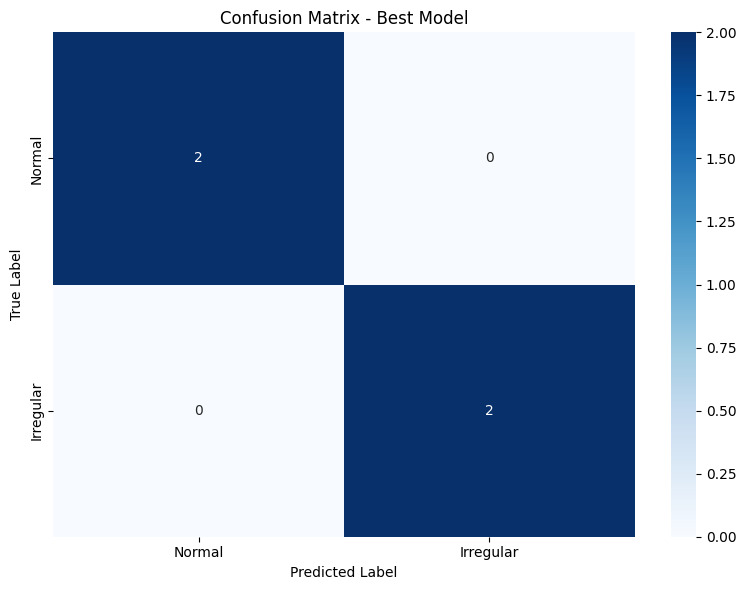


REAL-TIME PERFORMANCE EVALUATION

--- Prediction Latency ---
Mean latency: 13.2651 ms
Median latency: 12.3038 ms
Std deviation: 2.6464 ms
Min latency: 11.9705 ms
Max latency: 24.5671 ms
95th percentile: 20.6526 ms

--- Prediction Stability Over Multiple Runs ---
Sample 0: Stability = 100.0%, True=Normal, Pred=Normal
Sample 1: Stability = 100.0%, True=Normal, Pred=Normal
Sample 2: Stability = 100.0%, True=Irregular, Pred=Irregular
Sample 3: Stability = 100.0%, True=Irregular, Pred=Irregular

--- Visualization: Prediction Latency Distribution ---


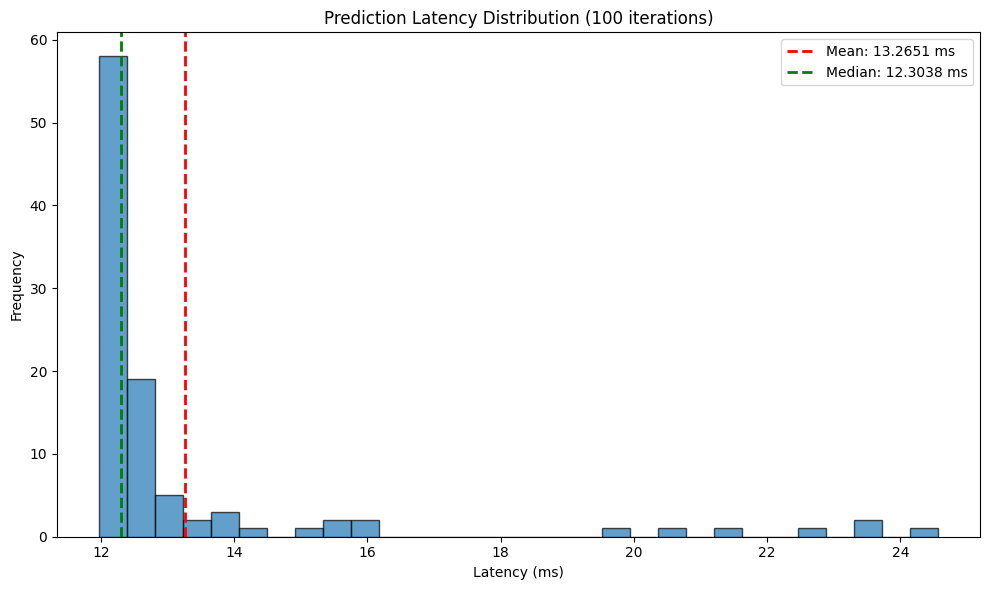

In [19]:
'''
### Error Analysis ###
- confusion matrix
- Identify missed irregular breathing cases

### Real-Time Performance ###
- latency of predictions
- stability over continuous sensing

'''


import time
import seaborn as sns

print("=" * 80)
print("ERROR ANALYSIS & MODEL EVALUATION")
print("=" * 80)

cm = confusion_matrix(y_test, y_best)
print("\n--- Confusion Matrix ---")
print(cm)
print(f"\nTrue Negatives (Normal, predicted Normal): {cm[0, 0]}")
print(f"False Positives (Normal, predicted Irregular): {cm[0, 1]}")
print(f"False Negatives (Irregular, predicted Normal): {cm[1, 0]}")
print(f"True Positives (Irregular, predicted Irregular): {cm[1, 1]}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_best, target_names=CLASS_NAMES))

print("\n--- Error Analysis: Missed Irregular Cases ---")
missed_indices = np.where((y_test == 1) & (y_best == 0))[0]
if len(missed_indices) > 0:
    print(f"Number of missed irregular cases: {len(missed_indices)}")
    for idx in missed_indices:
        print(f"  - Test sample {idx}: {meta.iloc[np.where(np.isin(range(len(meta)), [idx]))]['label'].values}")
else:
    print("No missed irregular cases! All irregular breathing patterns were correctly identified.")

print("\n--- Visualization: Confusion Matrix ---")
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - Best Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("REAL-TIME PERFORMANCE EVALUATION")
print("=" * 80)

print("\n--- Prediction Latency ---")
n_iterations = 100
latencies = []

for _ in range(n_iterations):
    sample = X_test[0:1]
    start_time = time.time()
    _ = best_model.predict(sample)
    end_time = time.time()
    latency_ms = (end_time - start_time) * 1000
    latencies.append(latency_ms)

latencies = np.array(latencies)
print(f"Mean latency: {np.mean(latencies):.4f} ms")
print(f"Median latency: {np.median(latencies):.4f} ms")
print(f"Std deviation: {np.std(latencies):.4f} ms")
print(f"Min latency: {np.min(latencies):.4f} ms")
print(f"Max latency: {np.max(latencies):.4f} ms")
print(f"95th percentile: {np.percentile(latencies, 95):.4f} ms")

print("\n--- Prediction Stability Over Multiple Runs ---")
stability_results = []
for sample_idx in range(min(5, len(X_test))):
    predictions = [best_model.predict(X_test[sample_idx:sample_idx+1])[0] for _ in range(10)]
    stability = np.mean(predictions == predictions[0])
    stability_results.append({
        'sample': sample_idx,
        'true_label': CLASS_NAMES[y_test[sample_idx]],
        'stability': stability,
        'predicted_label': CLASS_NAMES[predictions[0]]
    })
    print(f"Sample {sample_idx}: Stability = {stability*100:.1f}%, True={CLASS_NAMES[y_test[sample_idx]]}, Pred={CLASS_NAMES[predictions[0]]}")

print("\n--- Visualization: Prediction Latency Distribution ---")
plt.figure(figsize=(10, 6))
plt.hist(latencies, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(np.mean(latencies), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(latencies):.4f} ms')
plt.axvline(np.median(latencies), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(latencies):.4f} ms')
plt.xlabel('Latency (ms)')
plt.ylabel('Frequency')
plt.title('Prediction Latency Distribution (100 iterations)')
plt.legend()
plt.tight_layout()
plt.show()




In [ ]:
# Visualize accelerometer signal
# plt.figure(figsize=(12, 4))
# plt.plot(accel_df['x'], label='X-axis')
# plt.plot(accel_df['y'], label='Y-axis')
# plt.plot(accel_df['z'], label='Z-axis')
# plt.title("Accelerometer Signal")
# plt.xlabel("Time")
# plt.ylabel("Acceleration")
# plt.legend()
# plt.show()

In [ ]:
# Extract features from accelerometer data
# def extract_accelerometer_features(df):

#     magnitude = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)

#     features = [
#         np.mean(magnitude),
#         np.std(magnitude),
#         np.max(magnitude),
#         np.min(magnitude),
#         np.var(magnitude)
#     ]

#     return np.array(features)